In [1]:
import numpy as np
import pandas as pd
import ast

In [2]:
df = pd.read_csv('D:\Projects\ecg-arrytmia-dl\data\ptb-xl\ptbxl_database.csv', index_col='ecg_id')
df = df[['filename_lr', 'scp_codes', 'strat_fold']]
df

,filename_lr,scp_codes,strat_fold
ecg_id,,,
1,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3
2,records100/00000/00002_lr,"{'NORM': 80.0, 'SBRAD': 0.0}",2
3,records100/00000/00003_lr,"{'NORM': 100.0, 'SR': 0.0}",5
4,records100/00000/00004_lr,"{'NORM': 100.0, 'SR': 0.0}",3
5,records100/00000/00005_lr,"{'NORM': 100.0, 'SR': 0.0}",4
...,...,...,...
21833,records100/21000/21833_lr,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...",7
21834,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",4
21835,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",2


In [3]:
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

In [4]:
print(type(df['scp_codes'].iloc[0]))
print(df['scp_codes'].iloc[0])

<class 'dict'>
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


In [5]:
scp = pd.read_csv('D:\Projects\ecg-arrytmia-dl\data\ptb-xl\scp_statements.csv', index_col=0)
scp = scp[['diagnostic_class']]
scp = scp[scp['diagnostic_class'].notna()]

In [6]:
superclass_mapping = scp['diagnostic_class'].to_dict()
superclass_mapping

{'NDT': 'STTC',
 'NST_': 'STTC',
 'DIG': 'STTC',
 'LNGQT': 'STTC',
 'NORM': 'NORM',
 'IMI': 'MI',
 'ASMI': 'MI',
 'LVH': 'HYP',
 'LAFB': 'CD',
 'ISC_': 'STTC',
 'IRBBB': 'CD',
 '1AVB': 'CD',
 'IVCD': 'CD',
 'ISCAL': 'STTC',
 'CRBBB': 'CD',
 'CLBBB': 'CD',
 'ILMI': 'MI',
 'LAO/LAE': 'HYP',
 'AMI': 'MI',
 'ALMI': 'MI',
 'ISCIN': 'STTC',
 'INJAS': 'MI',
 'LMI': 'MI',
 'ISCIL': 'STTC',
 'LPFB': 'CD',
 'ISCAS': 'STTC',
 'INJAL': 'MI',
 'ISCLA': 'STTC',
 'RVH': 'HYP',
 'ANEUR': 'STTC',
 'RAO/RAE': 'HYP',
 'EL': 'STTC',
 'WPW': 'CD',
 'ILBBB': 'CD',
 'IPLMI': 'MI',
 'ISCAN': 'STTC',
 'IPMI': 'MI',
 'SEHYP': 'HYP',
 'INJIN': 'MI',
 'INJLA': 'MI',
 'PMI': 'MI',
 '3AVB': 'CD',
 'INJIL': 'MI',
 '2AVB': 'CD'}

In [7]:
df['scp_codes']

ecg_id
1                 {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
2                             {'NORM': 80.0, 'SBRAD': 0.0}
3                               {'NORM': 100.0, 'SR': 0.0}
4                               {'NORM': 100.0, 'SR': 0.0}
5                               {'NORM': 100.0, 'SR': 0.0}
                               ...                        
21833    {'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...
21834             {'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}
21835                           {'ISCAS': 50.0, 'SR': 0.0}
21836                           {'NORM': 100.0, 'SR': 0.0}
21837                           {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, Length: 21837, dtype: object

In [8]:
def aggregate_diagnostic(y_dict):
    temp = []
    for key in y_dict.keys():
        if key in superclass_mapping:
            temp.append(superclass_mapping[key])
    return list(set(temp))


In [9]:
df['superclasses'] = df['scp_codes'].apply(aggregate_diagnostic)

In [10]:
df

,filename_lr,scp_codes,strat_fold,superclasses
ecg_id,,,,
1,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3,[NORM]
2,records100/00000/00002_lr,"{'NORM': 80.0, 'SBRAD': 0.0}",2,[NORM]
3,records100/00000/00003_lr,"{'NORM': 100.0, 'SR': 0.0}",5,[NORM]
4,records100/00000/00004_lr,"{'NORM': 100.0, 'SR': 0.0}",3,[NORM]
5,records100/00000/00005_lr,"{'NORM': 100.0, 'SR': 0.0}",4,[NORM]
...,...,...,...,...
21833,records100/21000/21833_lr,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...",7,[STTC]
21834,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",4,[NORM]
21835,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",2,[STTC]


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

In [12]:
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(df['superclasses'])

In [13]:
target_classes = mlb.classes_
target_classes #gives the order of classes

array(['CD', 'HYP', 'MI', 'NORM', 'STTC'], dtype=object)

In [14]:
binary_matrix

array([[0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0],
       ...,
       [0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0]], shape=(21837, 5))

In [15]:
binary_df = pd.DataFrame(binary_matrix, columns=target_classes, index=df.index)
df = df.join(binary_df)

In [16]:
df

,filename_lr,scp_codes,strat_fold,superclasses,CD,HYP,MI,NORM,STTC
ecg_id,,,,,,,,,
1,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",3,[NORM],0,0,0,1,0
2,records100/00000/00002_lr,"{'NORM': 80.0, 'SBRAD': 0.0}",2,[NORM],0,0,0,1,0
3,records100/00000/00003_lr,"{'NORM': 100.0, 'SR': 0.0}",5,[NORM],0,0,0,1,0
4,records100/00000/00004_lr,"{'NORM': 100.0, 'SR': 0.0}",3,[NORM],0,0,0,1,0
5,records100/00000/00005_lr,"{'NORM': 100.0, 'SR': 0.0}",4,[NORM],0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
21833,records100/21000/21833_lr,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST...",7,[STTC],0,0,0,0,1
21834,records100/21000/21834_lr,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}",4,[NORM],0,0,0,1,0
21835,records100/21000/21835_lr,"{'ISCAS': 50.0, 'SR': 0.0}",2,[STTC],0,0,0,0,1


In [17]:
import wfdb

def load_ecg_waveform(relative_path, dataset_root_path):
    """
    Loads a raw WFDB file and formats it for a PyTorch 1D-CNN.
    """
    # 1. Combine the root directory with the specific file path
    # Example: 'C:/Downloads/ptb-xl/' + 'records100/00000/00001_lr'
    full_path = dataset_root_path + relative_path

    # 2. Read the waveform
    # wfdb.rdsamp returns a tuple: (the numpy array of the signal, a dictionary of metadata)
    # We only care about the signal array, so we ignore the metadata with '_'
    signal, _ = wfdb.rdsamp(full_path)

    # 3. The PyTorch Axis Flip (Crucial Step)
    # wfdb loads the array as (Time Steps, Channels) -> (1000, 12)
    # PyTorch's nn.Conv1d strictly demands (Channels, Time Steps) -> (12, 1000)
    signal_transposed = np.transpose(signal)

    # Ensure it's a float32 type, which PyTorch neural networks require for weights
    return signal_transposed.astype(np.float32)

In [18]:
import os
# Grab the very first relative path from your dataframe

test_path = df['filename_lr'].iloc[0]

# Run our function
# Make sure your root path ends with a slash! (e.g., 'D:/datasets/ptb-xl/')
test_signal = load_ecg_waveform(test_path, dataset_root_path = 'D:/Projects/ecg-arrytmia-dl/data/ptb-xl/')

print("Signal Shape:", test_signal.shape)
print("Data Type:", test_signal.dtype)

Signal Shape: (12, 1000)
Data Type: float32


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

class PTBXLDataset(Dataset):
    def __init__(self, df, dataset_root_path, target_columns):
        """
        Initializes the dataset factory.
        df: The pandas dataframe (can be train, val, or test)
        dataset_root_path: String path to your PTB-XL folder
        target_columns: List of the 5 superclass column names
        """
        # We reset the index so we can iterate cleanly from 0 to len(df)
        self.df = df.reset_index(drop=True)
        self.dataset_root_path = dataset_root_path
        self.target_columns = target_columns

    def __len__(self):
        """Tells PyTorch exactly how many ECGs are in this specific dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        The core engine. PyTorch calls this function to get a single patient's data.
        """
        # 1. Get the file path for this specific row
        relative_path = self.df.loc[idx, 'filename_lr']

        # 2. Use our custom function to load and transpose the waveform
        signal_array = load_ecg_waveform(relative_path, self.dataset_root_path)

        # 3. Convert the numpy array into a PyTorch Tensor
        signal_tensor = torch.tensor(signal_array, dtype=torch.float32)

        # 4. Extract the 5 binary labels (0s and 1s) for this patient
        labels_array = self.df.loc[idx, self.target_columns].values.astype(float)

        # 5. Convert the labels into a PyTorch Tensor
        # CRITICAL: For Multi-Label classification (BCEWithLogitsLoss),
        # PyTorch strictly requires the labels to be float32, NOT integers!
        label_tensor = torch.tensor(labels_array, dtype=torch.float32)

        return signal_tensor, label_tensor

In [20]:
# 1. Split the dataframes using the strat_fold column
train_df = df[df['strat_fold'] <= 8]
val_df = df[df['strat_fold'] == 9]
test_df = df[df['strat_fold'] == 10]

# 2. Define exactly which columns contain our final 1s and 0s
# (These must match the exact names generated by the MultiLabelBinarizer earlier)
target_columns = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# 3. Instantiate the PyTorch Datasets
# Replace 'YOUR_PATH_HERE/' with your actual dataset root path
train_dataset = PTBXLDataset(train_df, 'YOUR_PATH_HERE/', target_columns)
val_dataset = PTBXLDataset(val_df, 'YOUR_PATH_HERE/', target_columns)
test_dataset = PTBXLDataset(test_df, 'YOUR_PATH_HERE/', target_columns)

In [21]:
train_df = df[df['strat_fold'] <= 8]
val_df = df[df['strat_fold'] == 9]
test_df = df[df['strat_fold'] == 10]

TARGET_COLUMNS= ['CD', 'HYP', 'MI', 'NORM', 'STTC']


In [22]:
from torch.utils.data import DataLoader

# 1. Define your global configuration variables at the top
DATASET_ROOT = 'D:/Projects/ecg-arrytmia-dl/data/ptb-xl/'
BATCH_SIZE = 32

# 2. Instantiate datasets using the variable
train_dataset = PTBXLDataset(train_df, DATASET_ROOT, TARGET_COLUMNS)
val_dataset = PTBXLDataset(val_df, DATASET_ROOT, TARGET_COLUMNS)
test_dataset = PTBXLDataset(test_df, DATASET_ROOT, TARGET_COLUMNS)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
test_signals, test_labels = next(iter(train_loader))

print("Batch Signal Shape:", test_signals.shape)
print("Batch Label Shape:", test_labels.shape)

Batch Signal Shape: torch.Size([32, 12, 1000])
Batch Label Shape: torch.Size([32, 5])


In [24]:
import torch.nn as nn

class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()

        # Block 1: (batch, 12, 1000) -> (batch, 32, 500)
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=12, out_channels=32, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 2: -> (batch, 64, 250)
        self.block2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=11, stride=1, padding=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 3: -> (batch, 128, 125)
        self.block3 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 4: -> (batch, 128, 62)
        self.block4 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 5: -> (batch, 256, 31)
        self.block5 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 6: -> (batch, 256, 15)
        self.block6 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Block 7: -> (batch, 256, 1)
        self.block7 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # The Classifier Head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=128, out_features=5)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        # Pass the extracted features through the dense classifier head
        x = self.head(x)

        return x

In [25]:
# 1. Instantiate the model
model = ECGClassifier()

# 2. Create a fake batch of data mimicking your DataLoader output
# Shape: (Batch Size of 32, 12 Channels, 1000 Time Steps)
dummy_input = torch.randn(32, 12, 1000)

# 3. Pass it through the network
output = model(dummy_input)

# 4. Print the final shape
print("Output Shape:", output.shape)

Output Shape: torch.Size([32, 5])


In [26]:
import torch.optim as optim
import torch

# 1. Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# --- PATCH: Extract the raw numpy array of labels from the training dataframe ---
train_labels = train_df[TARGET_COLUMNS].values

# 2. Compute pos_weight for class imbalance
# train_labels is now a numpy array, so we can sum across the rows
label_counts = train_labels.sum(axis=0)
total_samples = len(train_labels)
pos_weight = torch.tensor((total_samples - label_counts) / label_counts, dtype=torch.float32).to(device)

# 3. Define the Multi-Label Loss Function
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 4. Define the Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 5. LR scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

print(f"Model pushed to: {device}")
print(f"Pos weights per class: {pos_weight}")

Model pushed to: cuda
Pos weights per class: tensor([3.4583, 7.2230, 2.9738, 1.2928, 3.1596], device='cuda:0')


In [27]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,007,269


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for signals, labels in loader:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * signals.size(0)

            probs = torch.sigmoid(outputs)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    # macro-AUC across all 5 classes
    macro_auc = roc_auc_score(all_labels, all_probs, average='macro')

    return running_loss / len(loader.dataset), macro_auc


# --- Training loop ---
num_epochs = 100
patience = 15
best_val_auc = 0.0
patience_counter = 0

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate(model, val_loader, criterion, device)

    scheduler.step(val_auc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val macro-AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
        print(f"  ✓ New best model saved (AUC: {best_val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print(f"\nTraining complete. Best val macro-AUC: {best_val_auc:.4f}")

In [28]:
from sklearn.metrics import roc_auc_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for signals, labels in loader:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * signals.size(0)

            probs = torch.sigmoid(outputs)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    macro_auc = roc_auc_score(all_labels, all_probs, average='macro')

    return running_loss / len(loader.dataset), macro_auc


# --- Training loop with crash safety net ---
num_epochs = 100
patience = 15
best_val_auc = 0.0
patience_counter = 0

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

try:
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_auc = validate(model, val_loader, criterion, device)

        scheduler.step(val_auc)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val macro-AUC: {val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_model.pt')
            patience_counter = 0
            print(f"  ✓ New best model saved (AUC: {best_val_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    print(f"\nTraining complete. Best val macro-AUC: {best_val_auc:.4f}")

except Exception as e:
    print(f"\n⚠️ Training crashed at epoch {epoch+1}: {e}")
    torch.save(model.state_dict(), 'crash_checkpoint.pt')
    print("Crash checkpoint saved as 'crash_checkpoint.pt'")

finally:
    # Save history regardless of how the loop ended, so you don't lose the training curve data
    import json
    with open('training_history.json', 'w') as f:
        json.dump(history, f)
    print("Training history saved to 'training_history.json'")

Epoch 1/100 | Train Loss: 0.7099 | Val Loss: 0.6676 | Val macro-AUC: 0.8847
  ✓ New best model saved (AUC: 0.8847)
Epoch 2/100 | Train Loss: 0.6392 | Val Loss: 0.6185 | Val macro-AUC: 0.8998
  ✓ New best model saved (AUC: 0.8998)
Epoch 3/100 | Train Loss: 0.6146 | Val Loss: 0.6399 | Val macro-AUC: 0.9004
  ✓ New best model saved (AUC: 0.9004)
Epoch 4/100 | Train Loss: 0.5875 | Val Loss: 0.6007 | Val macro-AUC: 0.9080
  ✓ New best model saved (AUC: 0.9080)
Epoch 5/100 | Train Loss: 0.5715 | Val Loss: 0.5685 | Val macro-AUC: 0.9146
  ✓ New best model saved (AUC: 0.9146)
Epoch 6/100 | Train Loss: 0.5602 | Val Loss: 0.5699 | Val macro-AUC: 0.9166
  ✓ New best model saved (AUC: 0.9166)
Epoch 7/100 | Train Loss: 0.5481 | Val Loss: 0.6263 | Val macro-AUC: 0.9114
Epoch 8/100 | Train Loss: 0.5386 | Val Loss: 0.5874 | Val macro-AUC: 0.9137
Epoch 9/100 | Train Loss: 0.5312 | Val Loss: 0.6492 | Val macro-AUC: 0.9147
Epoch 10/100 | Train Loss: 0.5217 | Val Loss: 0.5902 | Val macro-AUC: 0.9164
Epoch

In [29]:
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_auc = validate(model, test_loader, criterion, device)
print(f"Test macro-AUC: {test_auc:.4f}")

Test macro-AUC: 0.9209


In [30]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_labels, all_probs = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        probs = torch.sigmoid(outputs)
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)

per_class_auc = roc_auc_score(all_labels, all_probs, average=None)
for cls, auc in zip(TARGET_COLUMNS, per_class_auc):
    print(f"{cls}: {auc:.4f}")

CD: 0.9114
HYP: 0.9021
MI: 0.9173
NORM: 0.9445
STTC: 0.9290


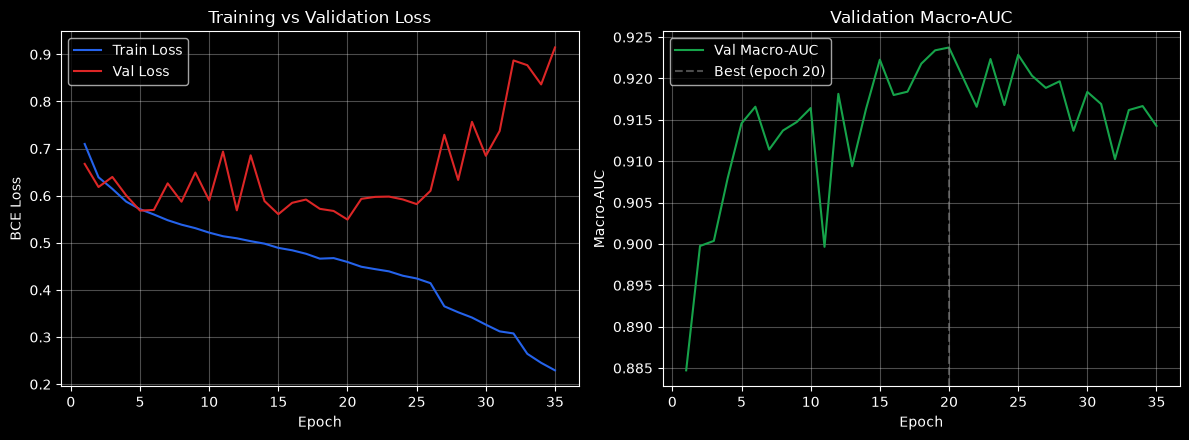

In [31]:
import json
import matplotlib.pyplot as plt

with open('training_history.json', 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Loss curves
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#2563eb')
axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='#dc2626')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC curve
axes[1].plot(epochs, history['val_auc'], label='Val Macro-AUC', color='#16a34a')
best_epoch = history['val_auc'].index(max(history['val_auc'])) + 1
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best (epoch {best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-AUC')
axes[1].set_title('Validation Macro-AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()